! Для работы анимаций требуется запуск кода вне тетради из-за ограничений jupyter notebook 

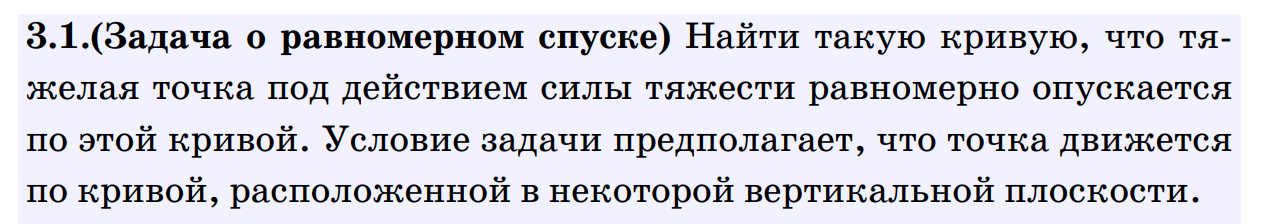

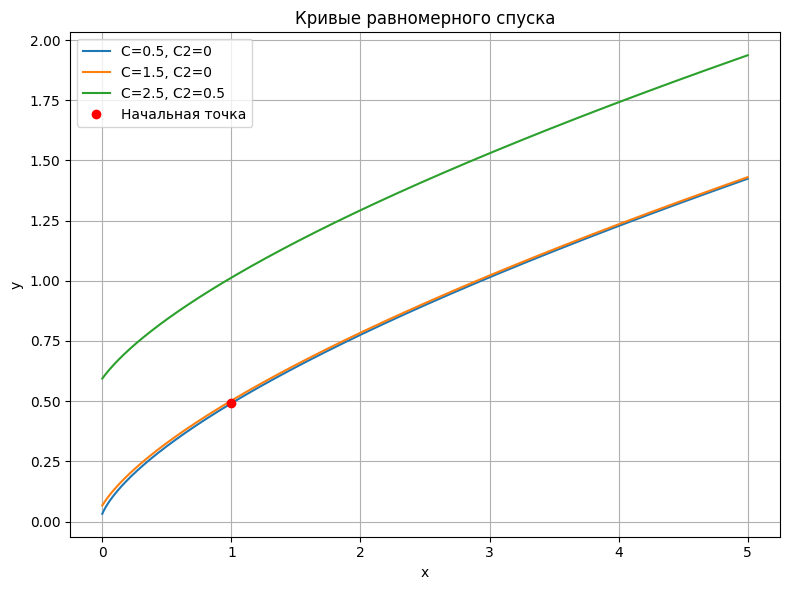

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
k = 1.0

def y_curve(x, C, C2):
    u = 3*g*x/k**2 + C
    return (k**2/(2*g))*u**(2/3) + C2

x = np.linspace(0, 5, 1000)

params = [(0.5, 0), (1.5, 0), (2.5, 0.5)]

plt.figure(figsize=(8,6))

for C, C2 in params:
    y = y_curve(x, C, C2)
    plt.plot(x, y, label=f"C={C}, C2={C2}")

x0 = 1
y0 = y_curve(x0, params[0][0], params[0][1])
plt.plot(x0, y0, 'ro', label="Начальная точка")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Кривые равномерного спуска")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("uniform_descent.png", dpi=300)
plt.show()


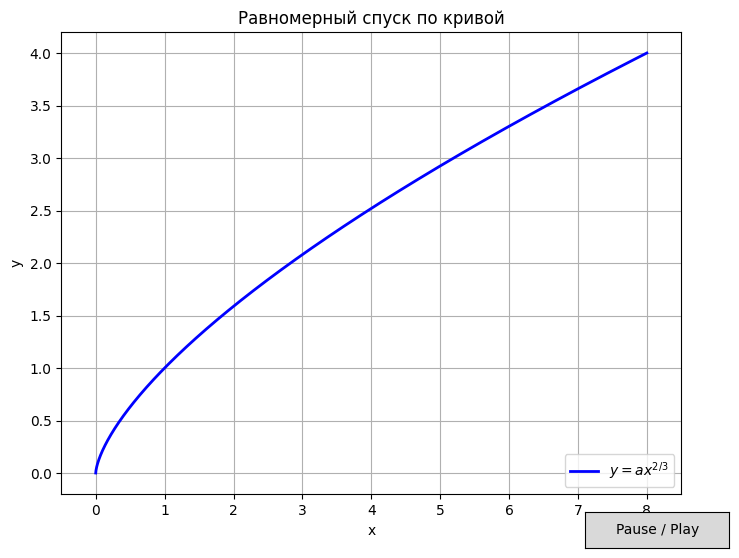

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Button

a = 1.0
k = 0.5
y0 = 4.0
fps = 30

y_curve = np.linspace(0, y0, 500)
x_curve = (y_curve / a)**(3/2)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(x_curve, y_curve, 'b', linewidth=2, label=r"$y=ax^{2/3}$")

point, = ax.plot([], [], 'ro', markersize=8)
time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.set_xlim(-0.5, max(x_curve)+0.5)
ax.set_ylim(-0.2, y0+0.2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Равномерный спуск по кривой")
ax.grid(True)
ax.legend()

t_max = y0 / k
frames = int(t_max * fps)

def init():
    point.set_data([], [])
    time_text.set_text("")
    return point, time_text

def update(frame):
    t = frame / fps
    y = y0 - k * t
    if y < 0:
        y = 0
    x = (y / a)**(3/2)
    point.set_data([x], [y])
    time_text.set_text(f"t = {t:.2f} c,  y = {y:.2f}")
    return point, time_text

anim = FuncAnimation(
    fig, update,
    frames=frames,
    init_func=init,
    interval=1000/fps,
    blit=True
)


paused = False

def toggle(event):
    global paused
    if paused:
        anim.event_source.start()
    else:
        anim.event_source.stop()
    paused = not paused

ax_button = plt.axes([0.78, 0.02, 0.18, 0.06])
btn = Button(ax_button, "Pause / Play")
btn.on_clicked(toggle)

plt.show()


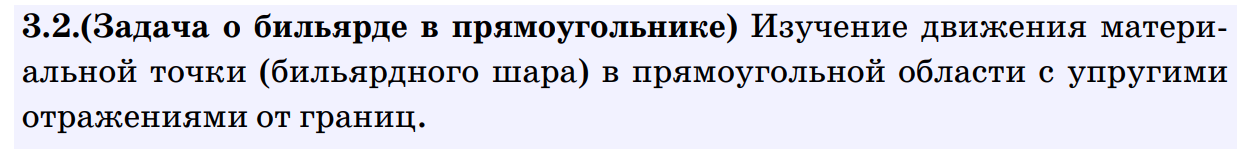

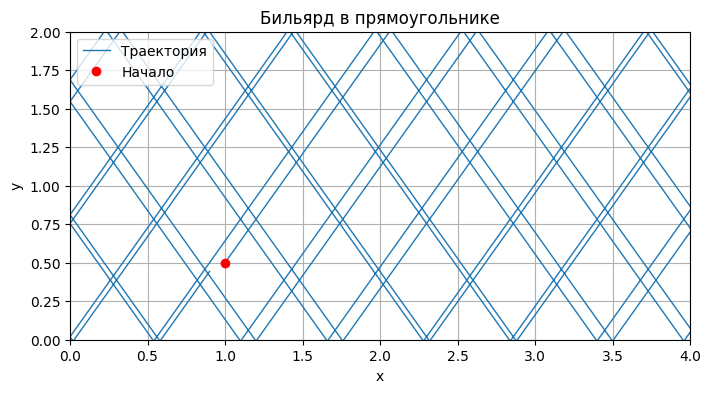

In [3]:
import numpy as np
import matplotlib.pyplot as plt

a, b = 4, 2
x0, y0 = 1.0, 0.5
vx, vy = 1.0, np.sqrt(2)   # иррациональный случай
T = 40
dt = 0.01

x, y = x0, y0
X, Y = [x], [y]

for _ in np.arange(0, T, dt):
    x += vx * dt
    y += vy * dt

    if x <= 0 or x >= a:
        vx *= -1
    if y <= 0 or y >= b:
        vy *= -1

    X.append(x)
    Y.append(y)

plt.figure(figsize=(8,4))
plt.plot(X, Y, lw=1, label="Траектория")
plt.plot(x0, y0, 'ro', label="Начало")
plt.xlim(0,a); plt.ylim(0,b)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Бильярд в прямоугольнике")
plt.grid(True)
plt.legend()
plt.savefig("billiard_trajectory.png", dpi=200)
plt.show()



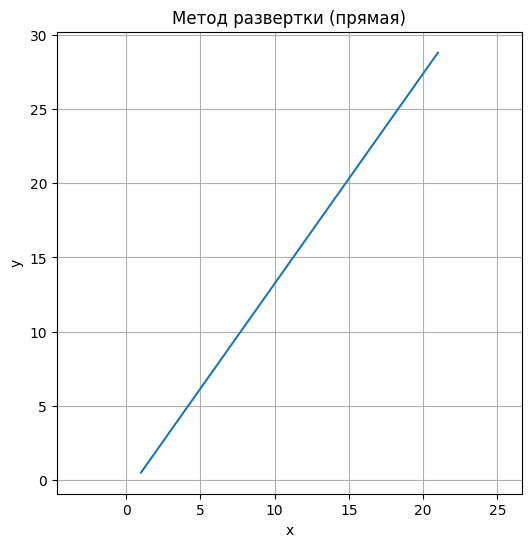

In [4]:
plt.figure(figsize=(6,6))
t = np.linspace(0, 20, 1000)
plt.plot(x0 + vx*t, y0 + vy*t)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Метод развертки (прямая)")
plt.grid(True)
plt.axis('equal')
plt.show()


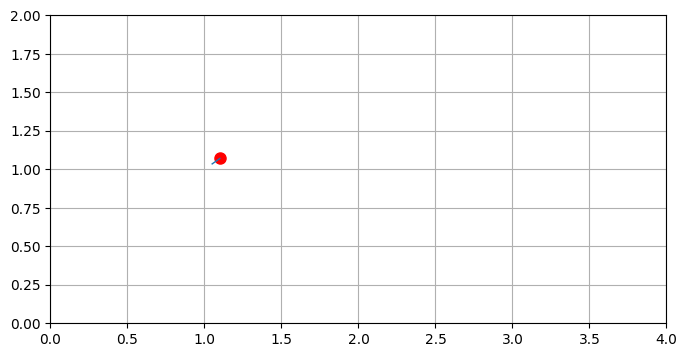

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

a, b = 4, 2
x0, y0 = 1.0, 1.0
vx, vy = 1.0, 0.7
dt = 0.05

fig, ax = plt.subplots(figsize=(8,4))
ax.set_xlim(0,a); ax.set_ylim(0,b)
ax.set_aspect('equal')
ax.grid(True)

ball, = ax.plot([], [], 'ro', ms=8)
traj, = ax.plot([], [], lw=1)

x, y = x0, y0
X, Y = [], []

def update(frame):
    global x, y, vx, vy
    x += vx * dt
    y += vy * dt

    if x <= 0 or x >= a:
        vx *= -1
    if y <= 0 or y >= b:
        vy *= -1

    X.append(x); Y.append(y)
    ball.set_data([x], [y])
    traj.set_data(X, Y)
    return ball, traj

anim = FuncAnimation(fig, update, frames=800, interval=30, blit=True)
plt.show()




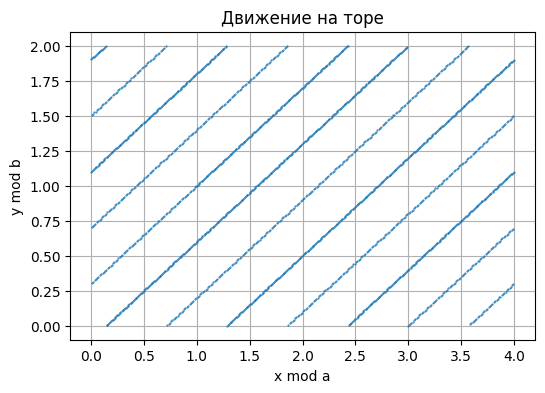

In [6]:
Lx, Ly = a, b
t = np.linspace(0, 50, 2000)

x_torus = (x0 + vx*t) % Lx
y_torus = (y0 + vy*t) % Ly

plt.figure(figsize=(6,4))
plt.plot(x_torus, y_torus, '.', ms=1)
plt.title("Движение на торе")
plt.xlabel("x mod a"); plt.ylabel("y mod b")
plt.grid(True)
plt.show()


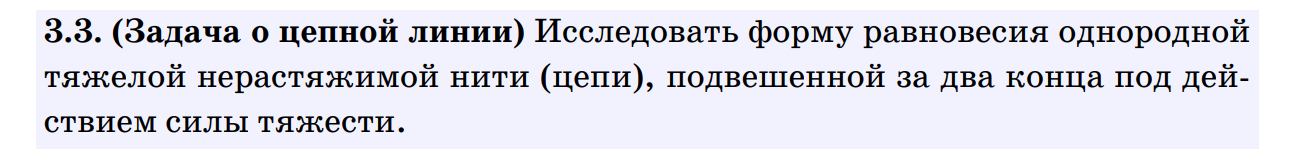

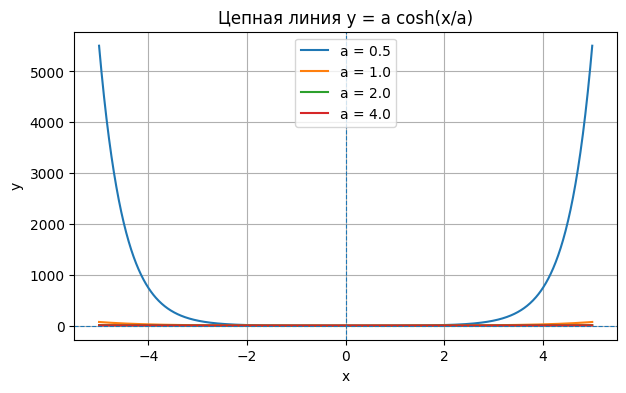

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 1000)
a_values = [0.5, 1.0, 2.0, 4.0]

plt.figure(figsize=(7, 4))

for a in a_values:
    y = a * np.cosh(x / a)
    plt.plot(x, y, label=f"a = {a}")

plt.axvline(0, linestyle="--", linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=0.8)

plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Цепная линия y = a cosh(x/a)")
plt.legend()

plt.savefig("catenary_static.png", dpi=300)
plt.show()


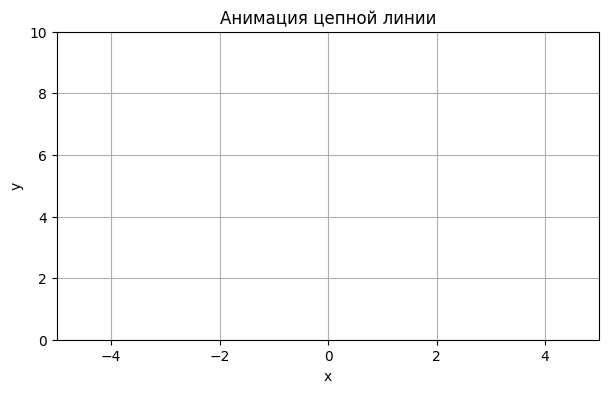

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = np.linspace(-5, 5, 600)
a_min, a_max = 0.5, 4.0
frames = 120

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(-5, 5)
ax.set_ylim(0, 10)
ax.grid(True)

line, = ax.plot([], [], lw=2)
text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Анимация цепной линии")

def init():
    line.set_data([], [])
    text.set_text("")
    return line, text

def update(frame):
    a = a_min + (a_max - a_min) * frame / frames
    y = a * np.cosh(x / a)

    rho_g = 1.0
    Tx = a * rho_g
    sag = y.max() - y.min()

    line.set_data(x, y)
    text.set_text(
        f"a = {a:.2f}\n"
        f"Tₓ ∝ {Tx:.2f}\n"
        f"Провисание ≈ {sag:.2f}"
    )
    return line, text

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=40,
    blit=True
)

plt.show()



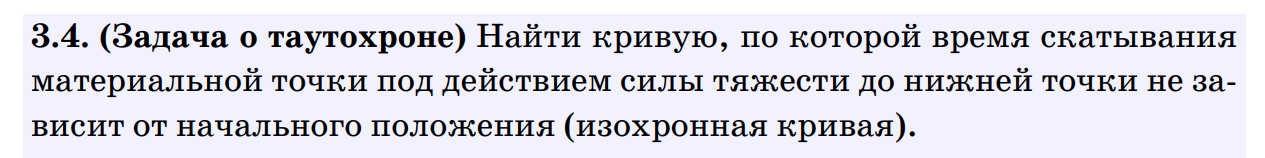

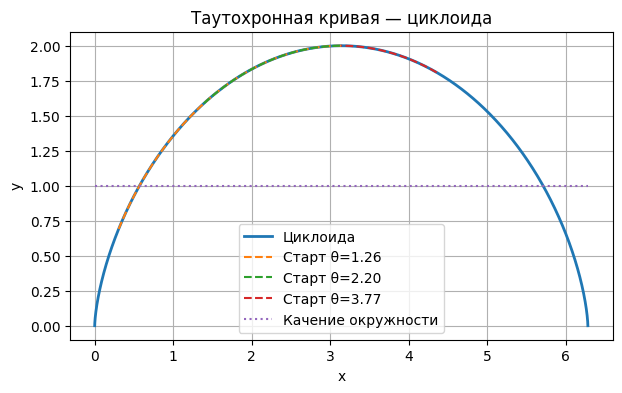

In [9]:
import numpy as np
import matplotlib.pyplot as plt

R = 1.0
theta = np.linspace(0, 2*np.pi, 1000)

x = R * (theta - np.sin(theta))
y = R * (1 - np.cos(theta))

plt.figure(figsize=(7, 4))
plt.plot(x, y, label="Циклоида", lw=2)

theta0_list = [0.4*np.pi, 0.7*np.pi, 1.2*np.pi]

for t0 in theta0_list:
    t = np.linspace(t0, np.pi, 300)
    xs = R * (t - np.sin(t))
    ys = R * (1 - np.cos(t))
    plt.plot(xs, ys, '--', label=f"Старт θ={t0:.2f}")

circle_x = R * theta
circle_y = R * np.ones_like(theta)
plt.plot(circle_x, circle_y, ':', label="Качение окружности")

plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Таутохронная кривая — циклоидa")
plt.legend()
plt.savefig("tautochrone_static.png", dpi=300)
plt.show()


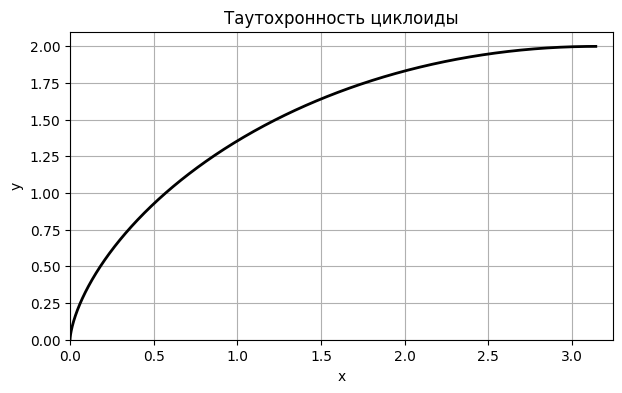

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

R = 1.0
g = 9.81
T = np.pi * np.sqrt(R / g)

theta = np.linspace(0, np.pi, 800)
x_curve = R * (theta - np.sin(theta))
y_curve = R * (1 - np.cos(theta))

theta0 = np.array([0.3*np.pi, 0.6*np.pi, 0.9*np.pi])
colors = ["red", "green", "blue"]

frames = 300
time = np.linspace(0, T, frames)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_curve, y_curve, color="black", lw=2)
ax.set_xlim(0, x_curve.max() + 0.1)
ax.set_ylim(0, y_curve.max() + 0.1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Таутохронность циклоиды")
ax.grid(True)

points = []
for c in colors:
    p, = ax.plot([], [], "o", color=c, markersize=8)
    points.append(p)

time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

def init():
    for p in points:
        p.set_data([], [])
    time_text.set_text("")
    return points + [time_text]

def update(frame):
    t = time[frame]

    for i in range(len(theta0)):
        theta_t = theta0[i] * np.cos(np.pi * t / (2 * T))
        if theta_t < 0:
            theta_t = 0

        x = R * (theta_t - np.sin(theta_t))
        y = R * (1 - np.cos(theta_t))
        points[i].set_data([x], [y])

    time_text.set_text(
        f"t = {t:.2f} c\n"
        f"T = {T:.2f} c (одинаково для всех)"
    )
    return points + [time_text]

ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=30,
    blit=True
)

plt.show()


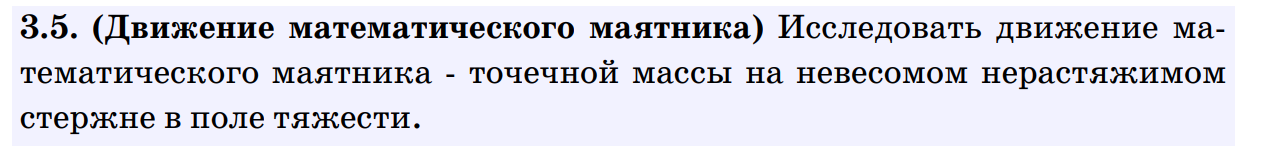


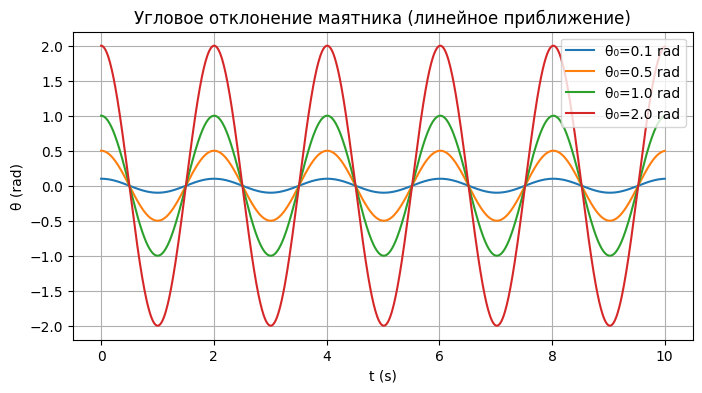

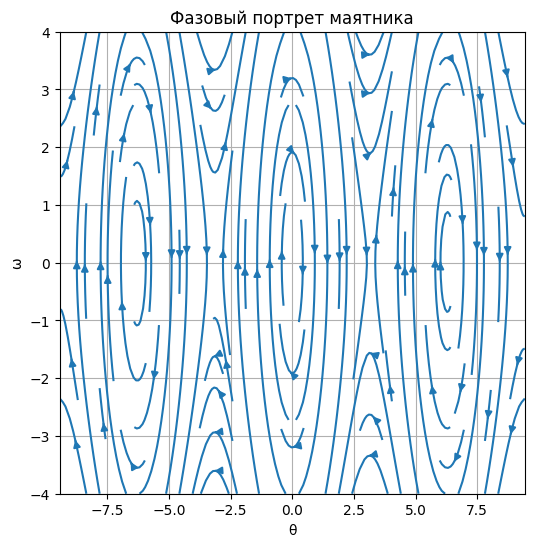

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk

g = 9.81
l = 1.0

theta0_list = [0.1, 0.5, 1.0, 2.0]

t_max = 10
t = np.linspace(0, t_max, 1000)

plt.figure(figsize=(8,4))

for theta0 in theta0_list:
    omega0 = 0
    theta = theta0 * np.cos(np.sqrt(g/l) * t)
    plt.plot(t, theta, label=f'θ₀={theta0:.1f} rad')

plt.xlabel('t (s)')
plt.ylabel('θ (rad)')
plt.title('Угловое отклонение маятника (линейное приближение)')
plt.grid(True)
plt.legend()
plt.savefig('pendulum_linear.png', dpi=300)
plt.show()

theta = np.linspace(-3*np.pi, 3*np.pi, 400)
omega = np.linspace(-4, 4, 400)
Theta, Omega = np.meshgrid(theta, omega)
dTheta = Omega
dOmega = - (g/l) * np.sin(Theta)

plt.figure(figsize=(6,6))
plt.streamplot(Theta, Omega, dTheta, dOmega, density=1.2)
plt.title('Фазовый портрет маятника')
plt.xlabel('θ')
plt.ylabel('ω')
plt.grid(True)
plt.savefig('pendulum_phase.png', dpi=300)
plt.show()



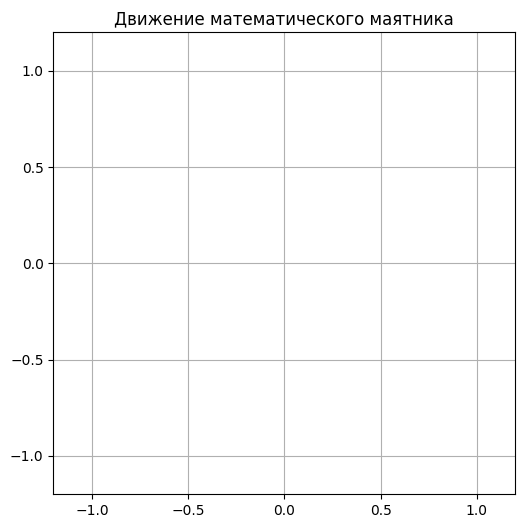

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

g = 9.81
l = 1.0

theta0_list = [0.2, 0.5, 1.0, 2.0]
colors = ['red','green','blue','orange']

t_max = 10
N = 500
t = np.linspace(0, t_max, N)

theta_all = []
for theta0 in theta0_list:
    theta = theta0 * np.cos(np.sqrt(g/l) * t)
    theta_all.append(theta)

fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-l-0.2, l+0.2)
ax.set_ylim(-l-0.2, l+0.2)
ax.set_aspect('equal')
ax.grid(True)
ax.set_title('Движение математического маятника')

lines = []
points = []
for color in colors:
    line, = ax.plot([], [], lw=2, color=color)
    point, = ax.plot([], [], 'o', color=color)
    lines.append(line)
    points.append(point)

def init():
    for line, point in zip(lines, points):
        line.set_data([], [])
        point.set_data([], [])
    return lines + points

def update(frame):
    for i, theta in enumerate(theta_all):
        x = l * np.sin(theta[frame])
        y = -l * np.cos(theta[frame])
        lines[i].set_data([0, x], [0, y])
        points[i].set_data([x], [y])
    return lines + points

ani = FuncAnimation(fig, update, frames=N, init_func=init,
                    interval=20, blit=True)

plt.show()
